# 加利福尼亚房价

In [19]:
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler
from torch.utils.data import Dataset, DataLoader
import torch

# 加载加利福尼亚房价数据
california = fetch_california_housing(data_home = './data')
X = california.data          # 特征
y = california.target        # 房价

# 对特征进行归一化（标准化处理：均值为0，方差为1）
scaler = StandardScaler()
X = scaler.fit_transform(X)


# 封装为自定义的Dataset
class CaliforniaHousingDataset(Dataset):
    def __init__(self, features, targets):
        self.features = torch.tensor(features, dtype=torch.float32)
        self.targets = torch.tensor(targets, dtype=torch.float32).unsqueeze(1) # 变成列向量

    def __len__(self):
        return len(self.features)

    def __getitem__(self, idx):
        return self.features[idx], self.targets[idx]

# 划分训练集、验证集和测试集
from sklearn.model_selection import train_test_split

# 先划分出测试集（20%），剩下的用于训练和验证
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 再从剩下的80%数据中划分出验证集（20%），即最终验证集占全体16%
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.2, random_state=42
)

# 分别构造训练集、验证集和测试集的Dataset
train_dataset = CaliforniaHousingDataset(X_train, y_train)
val_dataset = CaliforniaHousingDataset(X_val, y_val)
test_dataset = CaliforniaHousingDataset(X_test, y_test)

# 构造DataLoader
train_dataloader = DataLoader(train_dataset, batch_size=256, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=256, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [20]:
train_dataset[0]

(tensor([ 0.4402, -0.1303,  0.4423,  0.0414, -0.4879,  0.0301,  1.1087, -0.6989]),
 tensor([1.7690]))

In [21]:
import torch.nn as nn

# 搭建回归模型，隐藏层30个神经元，输出层一个
class RegressionModel(nn.Module):
    def __init__(self, input_dim):
        super(RegressionModel, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 30),
            nn.ReLU(),
            nn.Linear(30, 1)
        )

    def forward(self, x):
        return self.net(x)

# 实例化模型
input_dim = X.shape[1]
model = RegressionModel(input_dim)

In [22]:
# 输出每层参数
for name, param in model.named_parameters():
    print(f"Layer: {name} | Size: {param.size()} | Values : {param[:5]}")

# 做一次前向计算
sample_X = torch.tensor(X_train[:1], dtype=torch.float32).unsqueeze(0)
output = model(sample_X)
print("前向计算输出: ", output)

Layer: net.0.weight | Size: torch.Size([30, 8]) | Values : tensor([[-0.0297, -0.1242,  0.1669, -0.2906,  0.1016, -0.3018,  0.0351,  0.1726],
        [ 0.3510,  0.1018, -0.0324, -0.0801, -0.2148, -0.1422,  0.3252,  0.0504],
        [ 0.3003, -0.2500, -0.1143, -0.2138,  0.0038,  0.1791, -0.1182,  0.1967],
        [-0.3010,  0.2289, -0.3267,  0.0924, -0.2138,  0.1070,  0.0868,  0.0397],
        [ 0.0530,  0.2574, -0.1569, -0.3201,  0.0079,  0.2838,  0.2852, -0.0419]],
       grad_fn=<SliceBackward0>)
Layer: net.0.bias | Size: torch.Size([30]) | Values : tensor([-0.1643,  0.0992, -0.1641,  0.0674,  0.0901], grad_fn=<SliceBackward0>)
Layer: net.2.weight | Size: torch.Size([1, 30]) | Values : tensor([[-0.0757, -0.0409, -0.0960,  0.0706,  0.0773,  0.1529, -0.0536,  0.0350,
         -0.0943,  0.1464, -0.1522, -0.0685,  0.0927, -0.0930, -0.1548, -0.0890,
          0.0358,  0.0598,  0.0923, -0.1020, -0.0308, -0.1731,  0.0614,  0.0088,
         -0.1233,  0.0777,  0.1205,  0.0643,  0.0831, -0.0788

Epoch [1/100], Train Loss: 1.3167, Val Loss: 0.6855
Best regression model saved at epoch 1.
Epoch [2/100], Train Loss: 0.5309, Val Loss: 0.5153
Best regression model saved at epoch 2.
Epoch [3/100], Train Loss: 0.4569, Val Loss: 0.4686
Best regression model saved at epoch 3.
Epoch [4/100], Train Loss: 0.4339, Val Loss: 0.4759
No improvement. Early stop counter: 1/10
Epoch [5/100], Train Loss: 0.4218, Val Loss: 0.4552
Best regression model saved at epoch 5.
Epoch [6/100], Train Loss: 0.4124, Val Loss: 0.4385
Best regression model saved at epoch 6.
Epoch [7/100], Train Loss: 0.4063, Val Loss: 0.4384
Best regression model saved at epoch 7.
Epoch [8/100], Train Loss: 0.3986, Val Loss: 0.4254
Best regression model saved at epoch 8.
Epoch [9/100], Train Loss: 0.3929, Val Loss: 0.4233
Best regression model saved at epoch 9.
Epoch [10/100], Train Loss: 0.3903, Val Loss: 0.4152
Best regression model saved at epoch 10.
Epoch [11/100], Train Loss: 0.3874, Val Loss: 0.4122
Best regression model sa

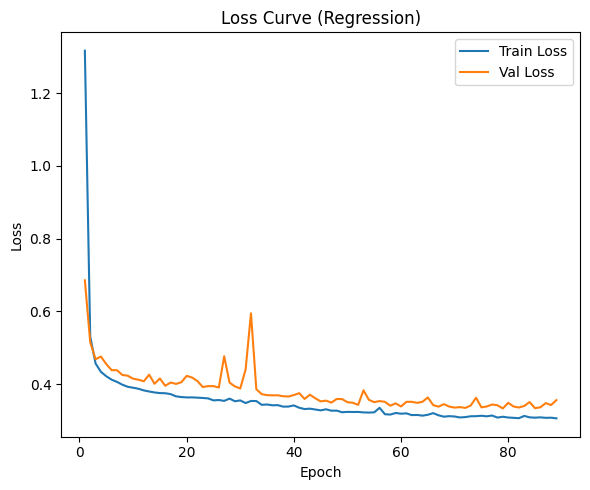

In [23]:
import torch.optim as optim
import torch.nn as nn

# 选择均方误差损失函数（MSELoss）
criterion = nn.MSELoss()

# 选择优化器，这里用Adam，也可以用SGD等
optimizer = optim.Adam(model.parameters(), lr=0.01)

from model_train import Trainer

# 用训练和验证dataloader初始化Trainer（指定回归损失函数）
trainer = Trainer(
    model, 
    train_dataloader, 
    val_dataloader, 
    lr=0.01, 
    momentum=0.9, 
    early_stop=True, 
    early_stop_mode='val_loss',
    patience=10,
    save_path='best_regression_model.pth'
)
# 指定回归任务的损失函数
trainer.criterion = nn.MSELoss()

# 进行回归任务训练
trainer.train_regression(epochs=100)

# 画出训练过程的损失曲线
trainer.plot_metrics(acc=False)

In [25]:
# 评估
trainer.evaluating(val_dataloader)

(0.0, 0.3333435562940744)